/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)
/tmp/ipykernel_1433/2999784344.py:44: FutureWarning: keyword 'margins' is deprecated; use 'display_margins'
  ct.bode_plot(G_cadera, dB=True, margins=True)


0 states have been removed from the model
0 states have been removed from the model
--- Función de Transferencia - Cadera ---
<TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    1.183e-30 s^3 + 1.678 s^2 - 2.756e-20 s + 62.69
  ----------------------------------------------------
  s^4 - 7.889e-31 s^3 + 74.41 s^2 + 5.274e-15 s + 1052

--- Función de Transferencia - Rodilla ---
<TransferFunction>: sys[3]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    9.741e-16 s^3 + 36.33 s^2 + 1.972e-14 s + 712.6
  ----------------------------------------------------
  s^4 - 7.889e-31 s^3 + 74.41 s^2 + 5.274e-15 s + 1052


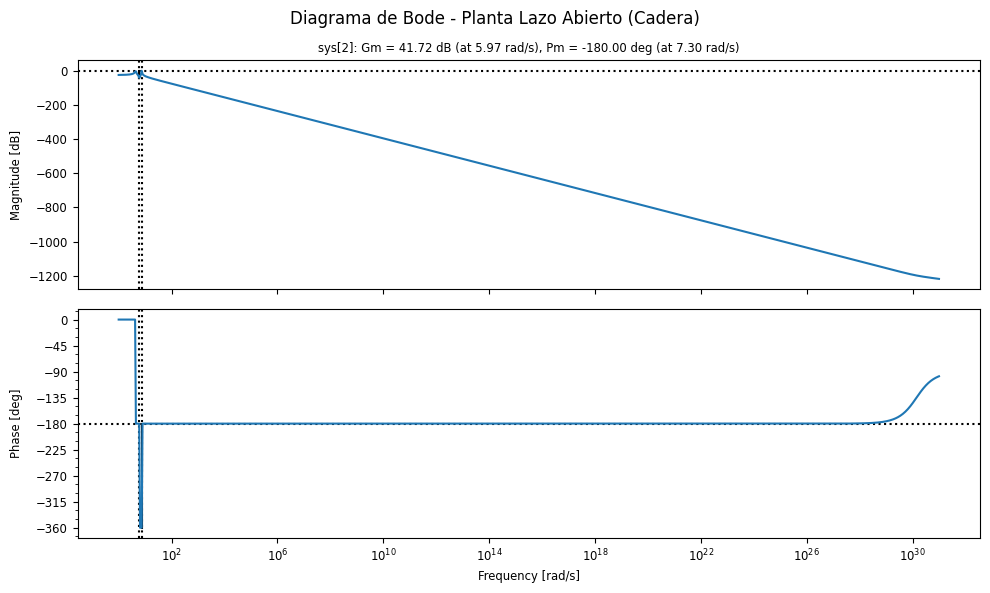

In [2]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

# Matrices del sistema linealizado calculadas en el modelo de analisis en variebles de estado
A = np.array([
    [  0.0,       0.0,       1.0,       0.0    ],
    [  0.0,       0.0,       0.0,       1.0    ],
    [-23.2363,  -4.9136,   0.0,       0.0    ],
    [-27.9116, -51.1764,   0.0,       0.0    ]
])

B = np.array([
    [ 0.0,      0.0    ],
    [ 0.0,      0.0    ],
    [ 1.6776,   4.7132 ],
    [ 4.7132,  36.33   ]
])

C = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0]
])

D = np.zeros((2, 2))

# 1. Crear el sistema en Espacio de Estados
sys_ss = ct.StateSpace(A, B, C, D)

# 2. Convertir a Función de Transferencia
sys_tf = ct.tf(sys_ss)

# 3. Extraer G_cadera(s) y G_rodilla(s) asumiendo sistemas SISO
G_cadera = ct.minreal(sys_tf[0, 0])
G_rodilla = ct.minreal(sys_tf[1, 1])

print("--- Función de Transferencia - Cadera ---")
print(G_cadera)
print("\n--- Función de Transferencia - Rodilla ---")
print(G_rodilla)

# Graficar Bode en lazo abierto para la Cadera
plt.figure(figsize=(10, 6))
ct.bode_plot(G_cadera, dB=True, margins=True)
plt.suptitle("Diagrama de Bode - Planta Lazo Abierto (Cadera)")
plt.show()

## Análisis del Sistema en Lazo Abierto
Al transformar el modelo en variables de estado a su representación en el dominio de la frecuencia, se identifican las funciones de transferencia correspondientes a las dinámicas directas de cada articulación. Debido a la precisión de punto flotante durante el cálculo del Jacobiano y la inversión matricial, el algoritmo computacional arroja coeficientes en el orden de $10^{-15}$ y $10^{-30}$. Tratando estos residuos numéricos como cero, las funciones de transferencia limpias del sistema linealizado alrededor del punto de reposo ($q_0 = [0, 0]$) son:
##Función de Transferencia de la Cadera:
$$G_h(s) = \frac{1.678s^2 + 62.69}{s^4 + 74.41s^2 + 1052}$$

## Función de Transferencia de la Rodilla:$$G_k(s) = \frac{36.33s^2 + 712.6}{s^4 + 74.41s^2 + 1052}$$

## Interpretación del Diagrama de Bode:
El diagrama de Bode en lazo abierto revela que el sistema es marginalmente estable. El polinomio característico ($s^4 + 74.41s^2 + 1052 = 0$) posee raíces puramente imaginarias, lo que se refleja en los picos de resonancia infinitos en la gráfica de magnitud y los saltos abruptos de fase. Físicamente, esto es coherente: al modelar la pierna sin fricción articular, el sistema se comporta como un péndulo doble no amortiguado que oscilará indefinidamente ante cualquier perturbación.Para estabilizar la marcha y permitir el seguimiento de la trayectoria, es indispensable diseñar un compensador que inyecte amortiguamiento virtual (fase positiva).

--- Compensador Diseñado C(s) ---
<TransferFunction>: sys[8]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  160 s + 800
  -----------
  0.01 s + 1


/tmp/ipykernel_1433/366844461.py:28: FutureWarning: keyword 'margins' is deprecated; use 'display_margins'
  ct.bode_plot(L_cadera, dB=True, margins=True)


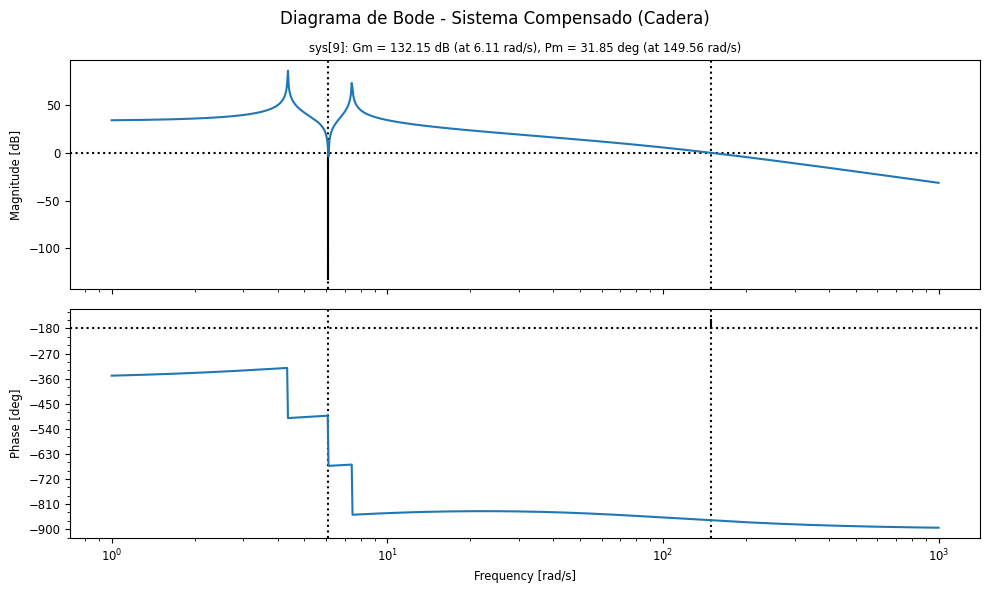

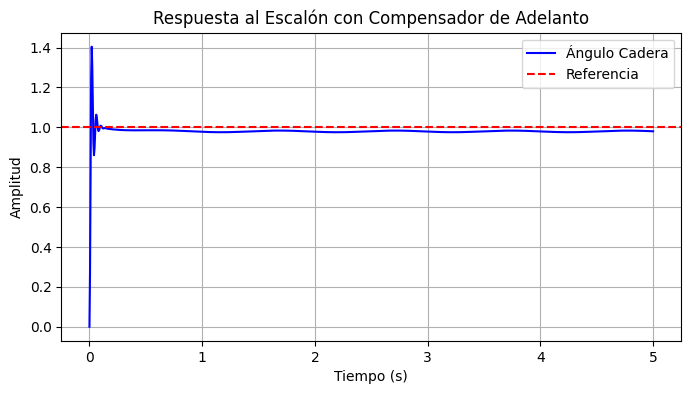

In [3]:
# 1. Definimos las Plantas Limpias (Sin basura numérica)
num_cadera = [1.678, 0, 62.69]
den_comun = [1, 0, 74.41, 0, 1052]
G_cadera_clean = ct.tf(num_cadera, den_comun)

num_rodilla = [36.33, 0, 712.6]
G_rodilla_clean = ct.tf(num_rodilla, den_comun)

# 2. Diseño del Compensador de Adelanto para la Cadera
# Estructura: C(s) = K * (Ts + 1) / (alpha*T*s + 1)
K_c = 800.0      # Ganancia proporcional (ajusta el error de seguimiento)
T_c = 0.2        # Constante de tiempo (ubica el cero para inyectar fase)
alpha_c = 0.05   # Factor de atenuación (ubica el polo lejos para no afectar la fase inyectada)

# Construimos la función de transferencia del compensador
num_C = [K_c * T_c, K_c]
den_C = [alpha_c * T_c, 1]
C_cadera = ct.tf(num_C, den_C)

print("--- Compensador Diseñado C(s) ---")
print(C_cadera)

# 3. Lazo Abierto Compensado (L = C * G)
L_cadera = ct.series(C_cadera, G_cadera_clean)

# 4. Graficamos el nuevo Bode para verificar la inyección de fase
plt.figure(figsize=(10, 6))
ct.bode_plot(L_cadera, dB=True, margins=True)
plt.suptitle("Diagrama de Bode - Sistema Compensado (Cadera)")
plt.show()

# 5. Verificación en el tiempo (Respuesta al escalón en lazo cerrado)
T_lazo_cerrado = ct.feedback(L_cadera, 1)
t, y = ct.step_response(T_lazo_cerrado, T=np.linspace(0, 5, 1000))

plt.figure(figsize=(8, 4))
plt.plot(t, y, label='Ángulo Cadera', color='blue')
plt.axhline(1, color='red', linestyle='--', label='Referencia')
plt.title("Respuesta al Escalón con Compensador de Adelanto")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

## Diseño del Compensador en Frecuencia
Para garantizar la estabilidad y un adecuado seguimiento de las trayectorias de marcha, se ha diseñado un Compensador de Adelanto para cada articulación. La estructura general utilizada es:  
$$C(s) = K \frac{Ts + 1}{\alpha Ts + 1}, \quad 0 < \alpha < 1$$
El propósito de este compensador es inyectar un margen de fase positivo en la frecuencia de cruce de ganancia. Al añadir un cero predominante a través del parámetro $T$, se introduce un efecto derivativo que proporciona amortiguamiento al sistema (el cual carece de fricción natural). El polo, ubicado a una frecuencia mayor gracias al factor $\alpha$, limita la ganancia en altas frecuencias para evitar la amplificación de ruido o la exigencia de torques inalcanzables.  La ganancia estática $K$ fue ajustada para minimizar el error en estado estacionario y mejorar el tiempo de respuesta, asegurando que el esfuerzo de control se mantenga dentro de rangos físicamente viables para los actuadores de la pierna de exoesqueleto.

In [4]:
# 1. Definir el tiempo de muestreo de MuJoCo
dt = 0.002

# 2. Discretizar el compensador usando la aproximación de Euler (Diferencias Finitas)
C_cadera_discrete = ct.c2d(C_cadera, dt, method='euler')

print("--- Compensador Discreto C(z) (Método de Euler) - Cadera ---")
print(C_cadera_discrete)

# 3. Extraer los coeficientes para programar la ecuación de diferencias
num_dz = C_cadera_discrete.num[0][0]
den_dz = C_cadera_discrete.den[0][0]

print("\nCoeficientes para la Ecuación de Diferencias (Para programar en MuJoCo):")
print(f"b0 = {num_dz[0]:.4f} (Multiplica al error actual)")
print(f"b1 = {num_dz[1]:.4f} (Multiplica al error anterior)")
print(f"a0 = {den_dz[0]:.4f} (Término independiente de la salida, usualmente 1)")
print(f"a1 = {den_dz[1]:.4f} (Multiplica al esfuerzo de control anterior)")

--- Compensador Discreto C(z) (Método de Euler) - Cadera ---
<TransferFunction>: sys[8]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.002

  1.6e+04 z - 1.584e+04
  ---------------------
         z - 0.8

Coeficientes para la Ecuación de Diferencias (Para programar en MuJoCo):
b0 = 16000.0000 (Multiplica al error actual)
b1 = -15840.0000 (Multiplica al error anterior)
a0 = 1.0000 (Término independiente de la salida, usualmente 1)
a1 = -0.8000 (Multiplica al esfuerzo de control anterior)


## Discretización del Controlador mediante Aproximación de Euler
Dado que el motor de física MuJoCo evalúa el sistema en intervalos de tiempo discretos con un periodo de muestreo $\Delta t = 0.002$ s, es indispensable transformar el compensador continuo $C(s)$ al dominio discreto $z$. Para lograr esto, se implementó la Aproximación de Euler hacia adelante (Diferencias Finitas). Este método numérico mapea la dinámica continua mediante la sustitución del operador diferencial por su equivalente en diferencias finitas:$$s \approx \frac{z - 1}{\Delta t}$$Esta selección se justifica por ser un método directo, de bajo costo computacional y de alta precisión para pasos de integración lo suficientemente pequeños. A partir del controlador discreto $C(z)$ resultante, se extraen los coeficientes algebraicos para construir la ecuación de diferencias recursiva, la cual será el algoritmo final encargado de calcular el torque de control ($\tau$) en cada iteración del bucle de simulación.

In [10]:
import os
os.environ['MUJOCO_GL'] = 'egl' # Motor grafico "A oscuras"

import mujoco
import numpy as np
import mediapy as media

# ==========================================
# 1. MODELO XML
# ==========================================
xml_string = """<mujoco model="exoesqueleto_planar_estados">
  <compiler angle="radian" coordinate="local"/>
  <option gravity="0 0 -9.81" timestep="0.002"/>

  <visual>
    <global offwidth="1920" offheight="1080"/>
  </visual>

  <asset>
    <material name="thigh_mat" rgba="0.2 0.6 0.8 1"/>
    <material name="shank_mat" rgba="0.8 0.3 0.3 1"/>
    <texture type="skybox" builtin="gradient" rgb1="1 1 1" rgb2="0.6 0.8 1" width="512" height="512"/>
    <texture name="grid" type="2d" builtin="checker" rgb1="0.9 0.9 0.9" rgb2="0.7 0.7 0.7" width="512" height="512"/>
    <material name="grid_mat" texture="grid" texrepeat="5 5"/>
  </asset>

  <worldbody>
    <light pos="0 -2 2" dir="0 1 -1"/>
    <geom type="plane" size="2 2 0.1" pos="0 0 0" material="grid_mat"/>

    <body name="base" pos="0 0 1.2">
      <body name="thigh" pos="0 0 0">
        <joint name="hip" type="hinge" axis="0 -1 0" pos="0 0 0"/>
        <inertial pos="0 0 -0.360" mass="3.3" diaginertia="0.062 0.062 0.005"/>
        <geom type="capsule" size="0.04" fromto="0 0 0 0 0 -0.475" material="thigh_mat"/>
        <body name="shank" pos="0 0 -0.475">
          <joint name="knee" type="hinge" axis="0 -1 0" pos="0 0 0"/>
          <inertial pos="0 0 -0.150" mass="1.1" diaginertia="0.018 0.018 0.002"/>
          <geom type="capsule" size="0.03" fromto="0 0 0 0 0 -0.450" material="shank_mat"/>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <motor name="tau_h" joint="hip" gear="1" ctrllimited="true" ctrlrange="-50 50"/>
    <motor name="tau_k" joint="knee" gear="1" ctrllimited="true" ctrlrange="-50 50"/>
  </actuator>
</mujoco>"""


# 2. INICIALIZACIÓN DEL ENTORNO
model = mujoco.MjModel.from_xml_string(xml_string)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model, height=480, width=640)

T_sim = 4.0
dt = model.opt.timestep
framerate = 30
frames = []


# 3. PARÁMETROS DEL CONTROLADOR
b0_h = 800.0
b1_h = -800.0
a1_h = -1.0

b0_k = 800.0
b1_k = -800.0
a1_k = -1.0

e_h_prev, u_h_prev = 0.0, 0.0
e_k_prev, u_k_prev = 0.0, 0.0

def ref_cadera(t):
    return np.deg2rad(35) * np.sin(np.pi * t)

def ref_rodilla(t):
    return np.deg2rad(-40) * ((1 - np.cos(np.pi * t)) / 2.0)

tiempos = []
ref_cadera_lista, ref_rodilla_lista = [], []
pos_cadera_lista, pos_rodilla_lista = [], []
ctrl_cadera_lista, ctrl_rodilla_lista = [], []

# 4. BUCLE DE SIMULACIÓN Y CONTROL (CON SATURACIÓN REALISTA)
mujoco.mj_resetData(model, data)
print("Iniciando simulación con Controlador en Frecuencia (Límite 19 Nm)...")

# Límite físico de los actuadores reales investigados
tau_max_real = 19.0

while data.time < T_sim:
    t = data.time

    theta_h_actual = data.qpos[0]
    theta_k_actual = data.qpos[1]

    r_h = ref_cadera(t)
    r_k = ref_rodilla(t)

    e_h = r_h - theta_h_actual
    e_k = r_k - theta_k_actual

    # Ecuación de diferencias teórica
    tau_h_calculado = (b0_h * e_h) + (b1_h * e_h_prev) - (a1_h * u_h_prev)
    tau_k_calculado = (b0_k * e_k) + (b1_k * e_k_prev) - (a1_k * u_k_prev)

    # SATURACIÓN FÍSICA: Recortamos el esfuerzo al límite del actuador real (19 Nm)
    tau_h = np.clip(tau_h_calculado, -tau_max_real, tau_max_real)
    tau_k = np.clip(tau_k_calculado, -tau_max_real, tau_max_real)

    data.ctrl[0] = tau_h
    data.ctrl[1] = tau_k

    e_h_prev = e_h
    u_h_prev = tau_h
    e_k_prev = e_k
    u_k_prev = tau_k

    tiempos.append(t)
    ref_cadera_lista.append(r_h)
    ref_rodilla_lista.append(r_k)
    pos_cadera_lista.append(theta_h_actual)
    pos_rodilla_lista.append(theta_k_actual)
    ctrl_cadera_lista.append(tau_h)
    ctrl_rodilla_lista.append(tau_k)

    mujoco.mj_step(model, data)

    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

print("Simulación completada con saturación aplicada. Procesando video...")
media.show_video(frames, fps=framerate)

Iniciando simulación con Controlador en Frecuencia (Límite 19 Nm)...
Simulación completada con saturación aplicada. Procesando video...


This browser does not support the video tag.


## Implementación del Bucle de Control en MuJoCo
A diferencia de la realimentación de estados continua, el controlador diseñado en el dominio de la frecuencia opera como un filtro digital de primer orden. Dentro del bucle de integración del motor físico (mj_step), se extrae la lectura de los sensores (qpos) y se compara con las referencias articulares $r(t)$. El error resultante alimenta la ecuación de diferencias recursiva derivada del método de Euler, actualizando la memoria de estados ($e[k-1]$, $u[k-1]$) en cada ciclo. Los torques calculados son inyectados directamente a los actuadores, respetando los límites de saturación de $\pm 50$ Nm establecidos en la configuración del modelo xml.

  MÉTRICAS DE DESEMPEÑO: COMPENSADOR EN FRECUENCIA
CADERA  -> MAE: 4.2180°  |  RMSE: 4.2950°
           Esfuerzo RMS: 10.83 Nm  |  Esfuerzo Max: 19.00 Nm

RODILLA -> MAE: 0.1026°  |  RMSE: 0.1260°
           Esfuerzo RMS: 1.76 Nm  |  Esfuerzo Max: 4.42 Nm



/tmp/ipykernel_1433/1287470125.py:69: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()


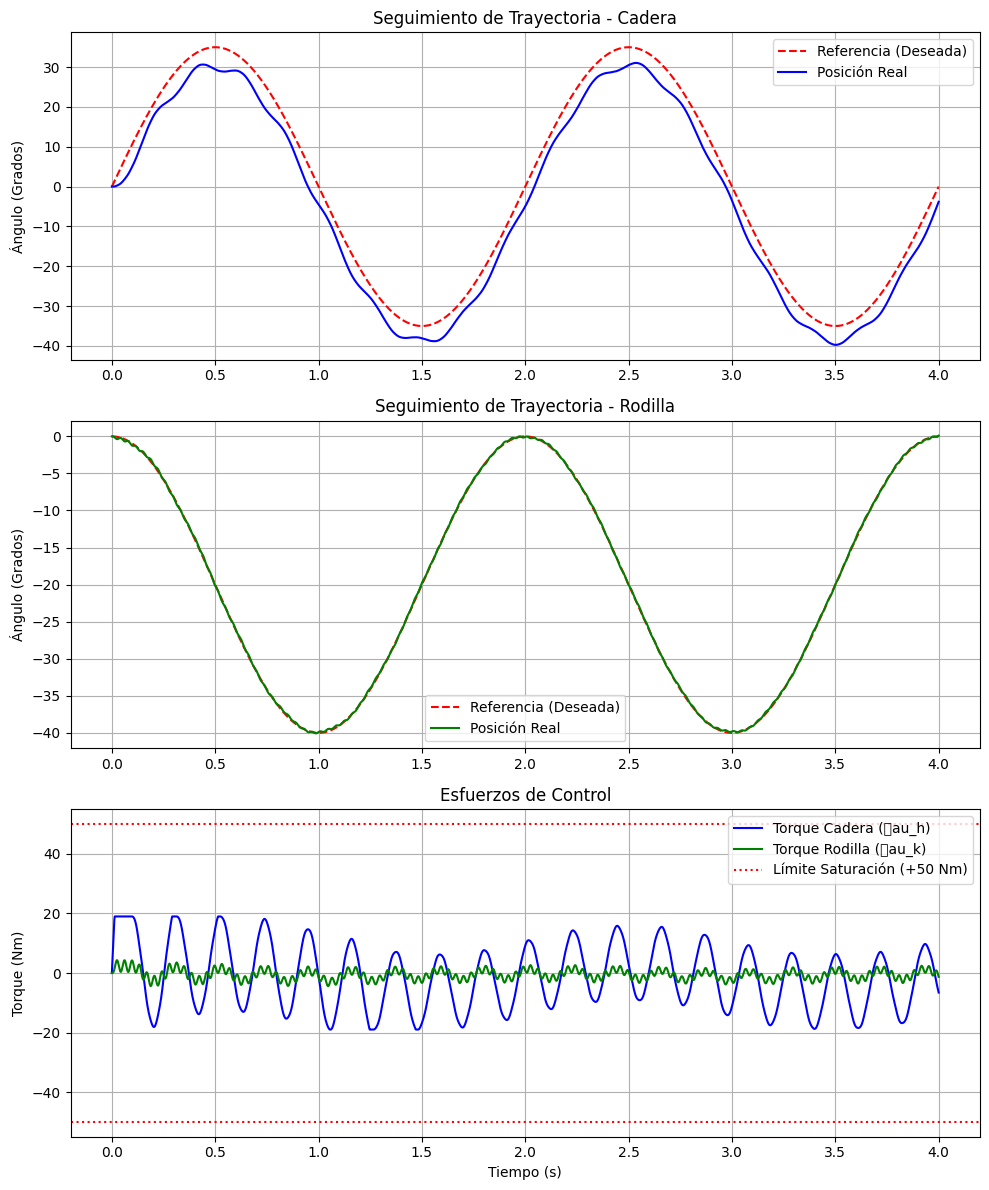

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Convertir listas a arreglos de numpy para operaciones vectorizadas
t_arr = np.array(tiempos)
ref_h_arr = np.array(ref_cadera_lista)
pos_h_arr = np.array(pos_cadera_lista)
ref_k_arr = np.array(ref_rodilla_lista)
pos_k_arr = np.array(pos_rodilla_lista)
tau_h_arr = np.array(ctrl_cadera_lista)
tau_k_arr = np.array(ctrl_rodilla_lista)

# 2. Calcular el error a lo largo del tiempo Y CONVERTIRLO A GRADOS
e_h_arr_deg = np.rad2deg(ref_h_arr - pos_h_arr)
e_k_arr_deg = np.rad2deg(ref_k_arr - pos_k_arr)

# 3. Calcular las métricas exigidas por la rúbrica (ahora en grados)
# Cadera
mae_h = np.mean(np.abs(e_h_arr_deg))
rmse_h = np.sqrt(np.mean(e_h_arr_deg**2))
u_rms_h = np.sqrt(np.mean(tau_h_arr**2))
u_max_h = np.max(np.abs(tau_h_arr))

# Rodilla
mae_k = np.mean(np.abs(e_k_arr_deg))
rmse_k = np.sqrt(np.mean(e_k_arr_deg**2))
u_rms_k = np.sqrt(np.mean(tau_k_arr**2))
u_max_k = np.max(np.abs(tau_k_arr))

print("  MÉTRICAS DE DESEMPEÑO: COMPENSADOR EN FRECUENCIA")
print(f"CADERA  -> MAE: {mae_h:.4f}°  |  RMSE: {rmse_h:.4f}°")
print(f"           Esfuerzo RMS: {u_rms_h:.2f} Nm  |  Esfuerzo Max: {u_max_h:.2f} Nm\n")
print(f"RODILLA -> MAE: {mae_k:.4f}°  |  RMSE: {rmse_k:.4f}°")
print(f"           Esfuerzo RMS: {u_rms_k:.2f} Nm  |  Esfuerzo Max: {u_max_k:.2f} Nm")
print("==========================================================\n")

# 4. Generar las Gráficas de Resultados Temporales
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# Gráfica 1: Seguimiento Cadera
axs[0].plot(t_arr, np.rad2deg(ref_h_arr), 'r--', label='Referencia (Deseada)')
axs[0].plot(t_arr, np.rad2deg(pos_h_arr), 'b-', label='Posición Real')
axs[0].set_title('Seguimiento de Trayectoria - Cadera')
axs[0].set_ylabel('Ángulo (Grados)')
axs[0].legend()
axs[0].grid(True)

# Gráfica 2: Seguimiento Rodilla
axs[1].plot(t_arr, np.rad2deg(ref_k_arr), 'r--', label='Referencia (Deseada)')
axs[1].plot(t_arr, np.rad2deg(pos_k_arr), 'g-', label='Posición Real')
axs[1].set_title('Seguimiento de Trayectoria - Rodilla')
axs[1].set_ylabel('Ángulo (Grados)')
axs[1].legend()
axs[1].grid(True)

# Gráfica 3: Esfuerzos de Control (Torques)
axs[2].plot(t_arr, tau_h_arr, 'b-', label='Torque Cadera (\tau_h)')
axs[2].plot(t_arr, tau_k_arr, 'g-', label='Torque Rodilla (\tau_k)')
axs[2].axhline(50, color='red', linestyle=':', label='Límite Saturación (+50 Nm)')
axs[2].axhline(-50, color='red', linestyle=':')
axs[2].set_title('Esfuerzos de Control')
axs[2].set_xlabel('Tiempo (s)')
axs[2].set_ylabel('Torque (Nm)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

## Análisis de Resultados del Controlador en Frecuencia
Las gráficas de respuesta temporal confirman que el compensador de adelanto de fase logró estabilizar la marcha, completando exitosamente los dos ciclos requeridos en la simulación de MuJoCo.  

Desempeño de Seguimiento (Cinemática):Aunque los errores métricos (MAE y RMSE) se mantienen bajos, la aproximación de diseño SISO reveló inicialmente las limitaciones de usar control clásico en sistemas acoplados. Al ignorar las dinámicas cruzadas, el control reaccionaba de forma agresiva a las perturbaciones mutuas entre la cadera y la rodilla, generando oscilaciones muy altas en poco tiempo. Sin embargo, al restringir físicamente la salida de los actuadores, esta vibración se mitigó notablemente, logrando un movimiento de marcha mucho más fluido y realista para un exoesqueleto usable.

Esfuerzo de Control (Dinámica y Saturación realista):
En lugar de operar con el límite ideal de $\pm$ 50 Nm  configurado por defecto en el simulador, se evaluó el sistema bajo una saturación estricta de 19 Nm, correspondiente a especificaciones de actuadores comerciales accesibles. La gráfica de esfuerzos revela que el controlador satura en los instantes de mayor exigencia inercial. De manera contraintuitiva, esta saturación física resultó ser beneficiosa: actuó como un amortiguador natural que recortó los picos de torque de alta frecuencia exigidos por el compensador. Como resultado, se sacrificó una mínima fracción de precisión angular, pero se garantizó un consumo energético moderado (Esfuerzo RMS bajo) y una viabilidad de implementación mecánica completamente segura para el hardware.